In [6]:
import os
from dotenv import load_dotenv
from databricks import sql

load_dotenv()

connection = sql.connect(
    server_hostname=os.getenv("DATABRICKS_SERVER_HOSTNAME"),
    http_path=os.getenv("DATABRICKS_HTTP_PATH"),
    access_token=os.getenv("DATABRICKS_TOKEN")
)

print("Databricks connection successful!")

Databricks connection successful!


In [7]:
import pandas as pd

query = """
SELECT *
FROM ecommerce_sales.ecommerce.gold_sales_features
ORDER BY order_date
"""

df = pd.read_sql(query, connection)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()
df.columns.tolist()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22488\62348622.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Rows: 180
Columns: 15


['order_date',
 'day',
 'day_of_week',
 'week',
 'month',
 'quarter',
 'is_weekend',
 'total_revenue',
 'revenue_lag_1',
 'revenue_lag_7',
 'revenue_lag_14',
 'revenue_lag_30',
 'revenue_rolling_7',
 'revenue_rolling_14',
 'revenue_rolling_30']

In [8]:
df_ml = df.dropna().copy()

print("Original rows:", len(df))
print("ML-ready rows:", len(df_ml))
print("Missing values:", df_ml.isna().sum().sum())

Original rows: 180
ML-ready rows: 150
Missing values: 0


In [9]:
# Make sure data is sorted by date
df_ml = df_ml.sort_values("order_date").reset_index(drop=True)

# Define features and target
features = [
    "day","day_of_week","week","month","quarter",
    "is_weekend","revenue_lag_1","revenue_lag_7",
    "revenue_lag_14","revenue_lag_30","revenue_rolling_7",
    "revenue_rolling_14","revenue_rolling_30"
]

target = "total_revenue"

X = df_ml[features]
y = df_ml[target]

# Chronological 80/20 split
split_index = int(len(df_ml) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining period:")
print(df_ml.iloc[:split_index]["order_date"].min())
print("to")
print(df_ml.iloc[:split_index]["order_date"].max())

print("\nTesting period:")
print(df_ml.iloc[split_index:]["order_date"].min())
print("to")
print(df_ml.iloc[split_index:]["order_date"].max())

Training rows: 120
Testing rows: 30

Training period:
2026-01-31
to
2026-05-30

Testing period:
2026-05-31
to
2026-06-29


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Baseline prediction: yesterday's revenue
baseline_pred = X_test["revenue_lag_1"]

# Evaluation metrics
baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

baseline_mape = np.mean(
    np.abs((y_test - baseline_pred) / y_test)
) * 100

print("Baseline Performance")
print("--------------------")
print(f"MAE  : ₹{baseline_mae:,.2f}")
print(f"RMSE : ₹{baseline_rmse:,.2f}")
print(f"MAPE : {baseline_mape:.2f}%")

Baseline Performance
--------------------
MAE  : ₹121,610.29
RMSE : ₹161,198.42
MAPE : 262.83%


In [11]:
print("Minimum actual revenue:", y_test.min())
print("Maximum actual revenue:", y_test.max())

print("\nActual revenue values:")
print(y_test.sort_values().head(10))

Minimum actual revenue: 13163.79
Maximum actual revenue: 442075.25

Actual revenue values:
123    13163.79
126    15466.28
136    18344.84
133    18389.36
124    37032.42
129    40734.78
147    45583.83
137    55869.48
125    56268.02
140    60427.88
Name: total_revenue, dtype: float64


In [13]:
from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

print("Linear Regression training completed!")

# Calculate Linear Regression metrics

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_mape = np.mean(
    np.abs((y_test - lr_pred) / y_test)) * 100

print("Linear Regression Performance")
print("-----------------------------")
print(f"MAE  : ₹{lr_mae:,.2f}")
print(f"RMSE : ₹{lr_rmse:,.2f}")
print(f"MAPE : {lr_mape:.2f}%")

Linear Regression training completed!
Linear Regression Performance
-----------------------------
MAE  : ₹99,846.54
RMSE : ₹116,240.10
MAPE : 195.86%


In [15]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest training completed!")

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print("Random Forest Performance")
print("------------------------")
print(f"MAE  : ₹{rf_mae:,.2f}")
print(f"RMSE : ₹{rf_rmse:,.2f}")
print(f"MAPE : {rf_mape:.2f}%")

Random Forest training completed!
Random Forest Performance
------------------------
MAE  : ₹92,069.43
RMSE : ₹108,779.33
MAPE : 188.17%


In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline (Previous Day)",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_rmse,
        rf_rmse
    ],
    "MAPE": [
        baseline_mape,
        lr_mape,
        rf_mape
    ]
})

comparison

,Model,MAE,RMSE,MAPE
0,Baseline (Previous Day),121610.285333,161198.417211,262.829258
1,Linear Regression,99846.541537,116240.100013,195.863874
2,Random Forest,92069.427469,108779.332834,188.169608


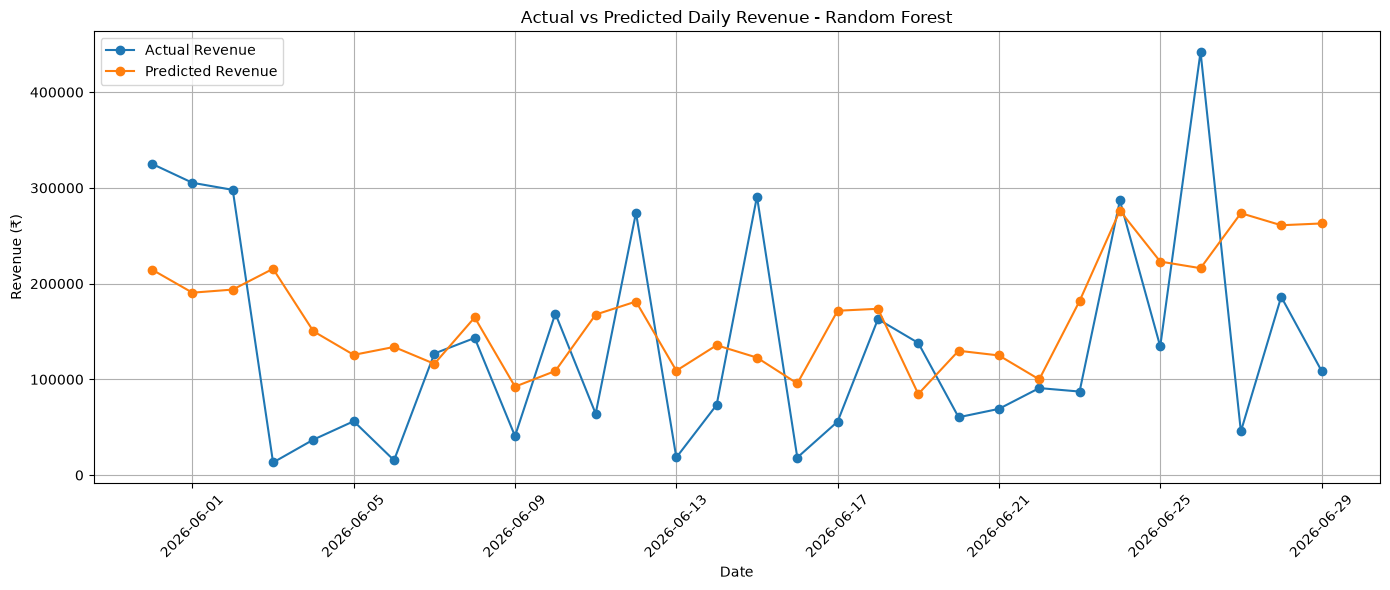

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    df_ml.loc[y_test.index, "order_date"],
    y_test.values,
    label="Actual Revenue",
    marker="o"
)

plt.plot(
    df_ml.loc[y_test.index, "order_date"],
    rf_pred,
    label="Predicted Revenue",
    marker="o"
)

plt.title("Actual vs Predicted Daily Revenue - Random Forest")
plt.xlabel("Date")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [18]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,day,0.165726
1,revenue_rolling_30,0.151618
2,revenue_lag_14,0.151260
3,revenue_rolling_14,0.136391
4,revenue_lag_7,0.081019
5,revenue_rolling_7,0.077633
6,revenue_lag_1,0.074576
7,revenue_lag_30,0.069351
8,week,0.041590
9,day_of_week,0.032021


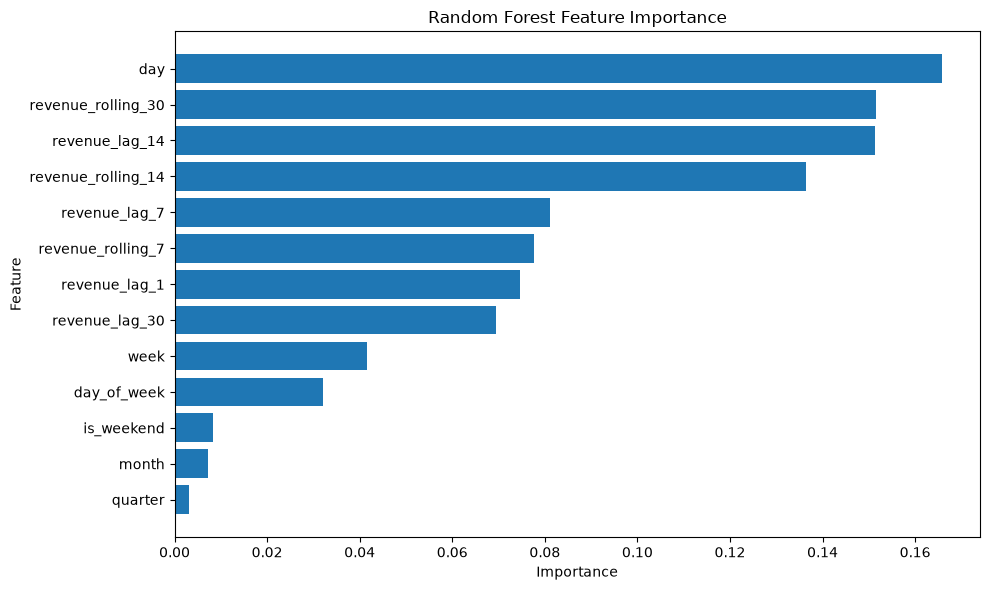

In [19]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

In [20]:
best_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X, y)

print("Final Random Forest model trained on all available data!")
print("Training rows:", len(X))

Final Random Forest model trained on all available data!
Training rows: 150


In [21]:
import pandas as pd
import numpy as np

# Historical revenue series
history = df[["order_date", "total_revenue"]].copy()
history["order_date"] = pd.to_datetime(history["order_date"])
history = history.sort_values("order_date").reset_index(drop=True)

# Store revenue values for recursive forecasting
revenue_history = history["total_revenue"].tolist()

# Last historical date
last_date = history["order_date"].max()

# Generate next 7 dates
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=7,
    freq="D"
)

forecast_results = []

for future_date in future_dates:

    # Calendar features
    day = future_date.day
    day_of_week = future_date.dayofweek
    week = future_date.isocalendar().week
    month = future_date.month
    quarter = future_date.quarter
    is_weekend = int(day_of_week >= 5)

    # Historical/previous predicted revenue features
    lag_1 = revenue_history[-1]
    lag_7 = revenue_history[-7]
    lag_14 = revenue_history[-14]
    lag_30 = revenue_history[-30]

    rolling_7 = np.mean(revenue_history[-7:])
    rolling_14 = np.mean(revenue_history[-14:])
    rolling_30 = np.mean(revenue_history[-30:])

    # Create model input
    future_features = pd.DataFrame([{
        "day": day,
        "day_of_week": day_of_week,
        "week": week,
        "month": month,
        "quarter": quarter,
        "is_weekend": is_weekend,
        "revenue_lag_1": lag_1,
        "revenue_lag_7": lag_7,
        "revenue_lag_14": lag_14,
        "revenue_lag_30": lag_30,
        "revenue_rolling_7": rolling_7,
        "revenue_rolling_14": rolling_14,
        "revenue_rolling_30": rolling_30
    }])

    # Predict revenue
    predicted_revenue = best_model.predict(future_features)[0]

    # Store prediction
    forecast_results.append({
        "order_date": future_date,
        "predicted_revenue": predicted_revenue
    })

    # Add prediction to history for recursive forecasting
    revenue_history.append(predicted_revenue)

forecast_df = pd.DataFrame(forecast_results)

forecast_df["predicted_revenue"] = forecast_df["predicted_revenue"].round(2)

forecast_df

,order_date,predicted_revenue
0,2026-06-30,312523.78
1,2026-07-01,266568.16
2,2026-07-02,242149.56
3,2026-07-03,142850.30
4,2026-07-04,106184.20
5,2026-07-05,97034.30
6,2026-07-06,100033.94


In [22]:
import os

# Create output folder
os.makedirs("output", exist_ok=True)

# Save 7-day forecast
forecast_df.to_csv(
    "output/7_day_sales_forecast.csv",
    index=False
)

# Save model comparison
comparison.to_csv(
    "output/model_comparison.csv",
    index=False
)

# Save feature importance
feature_importance.to_csv(
    "output/feature_importance.csv",
    index=False
)

print("ML outputs saved successfully!")

ML outputs saved successfully!


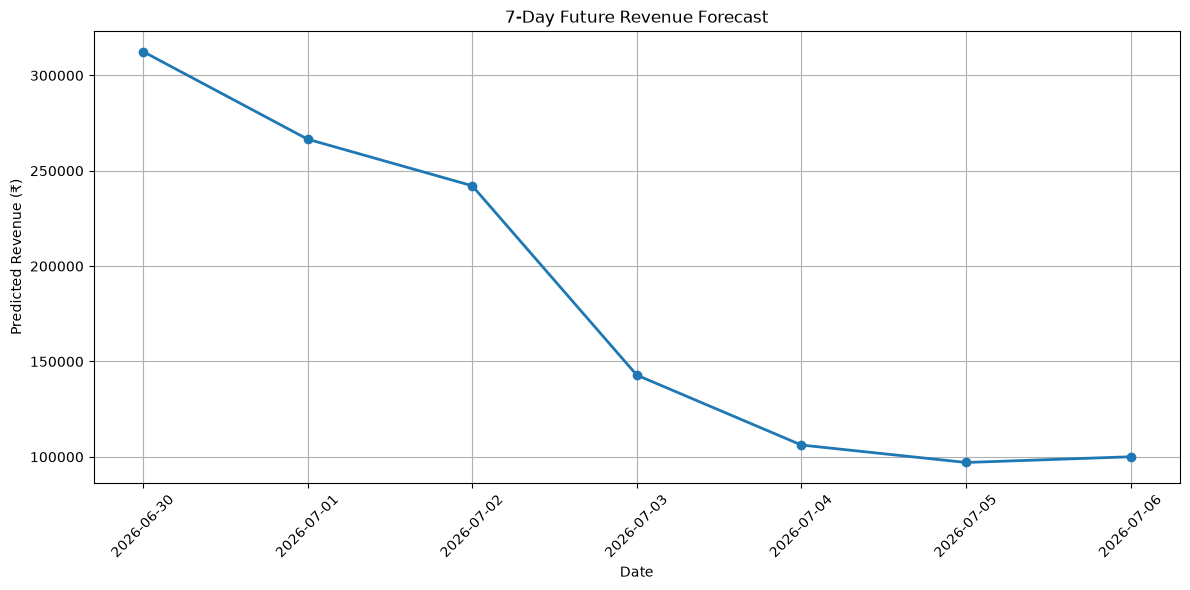

Forecast visualization saved!


In [23]:
plt.figure(figsize=(12, 6))

plt.plot(
    forecast_df["order_date"],
    forecast_df["predicted_revenue"],
    marker="o",
    linewidth=2
)

plt.title("7-Day Future Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Predicted Revenue (₹)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "output/7_day_sales_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Forecast visualization saved!")